Calculate inprop for central brain neurons on a signle neuron level. Optic lobe neurons are not included. Input from the optic lobe from the central brain is through the visual_projection neurons, which are preserved.  

In [1]:
import pandas as pd
import numpy as np
from scipy.sparse import coo_matrix
import scipy as sp
import matplotlib.pyplot as plt

# reading data

In [2]:
info = pd.read_csv(
    "https://raw.githubusercontent.com/flyconnectome/flywire_annotations/main/supplemental_files/Supplemental_file1_neuron_annotations.tsv",
    delimiter="\t",
)

info.columns

C:\Users\44745\AppData\Local\Temp\ipykernel_65524\611402832.py:1: DtypeWarning: Columns (14,15,16,17,23) have mixed types. Specify dtype option on import or set low_memory=False.
  info = pd.read_csv(


Index(['supervoxel_id', 'root_id', 'pos_x', 'pos_y', 'pos_z', 'soma_x',
       'soma_y', 'soma_z', 'nucleus_id', 'flow', 'super_class', 'cell_class',
       'cell_sub_class', 'cell_type', 'hemibrain_type', 'ito_lee_hemilineage',
       'hartenstein_hemilineage', 'morphology_group', 'top_nt', 'top_nt_conf',
       'known_nt', 'known_nt_source', 'side', 'nerve', 'vfb_id', 'fbbt_id',
       'status'],
      dtype='object')

In [3]:
info.super_class.value_counts(dropna=False)

super_class
optic                 77536
central               32388
sensory               16903
visual_projection      8053
ascending              2362
descending             1303
visual_centrifugal      524
motor                   106
endocrine                80
Name: count, dtype: int64

In [4]:
# to make the matrix smaller, let's take visual projection neurons as visual input, and remove the optic lobe neurons
cb = info[~info.super_class.isin(["optic"])]
# filter out the visual sensory neurons, except for the ocellar ones
cb = cb[(cb.cell_class != "visual") | (cb.cell_type == "ocellar retinula cell")]
cb

,supervoxel_id,root_id,pos_x,pos_y,pos_z,soma_x,soma_y,soma_z,nucleus_id,flow,...,morphology_group,top_nt,top_nt_conf,known_nt,known_nt_source,side,nerve,vfb_id,fbbt_id,status
0,78112261444987077,720575940628857210,109306,50491,3960,104904.0,47464.0,5461.0,2453924.0,intrinsic,...,NaN,acetylcholine,0.917977,NaN,NaN,left,NaN,fw138205,FBbt_20001935,NaN
1,82475466912542440,720575940626838909,172029,55635,1592,177472.0,56936.0,1429.0,7393349.0,intrinsic,...,VLPl2_medial__0,acetylcholine,0.645442,NaN,NaN,right,NaN,fw000001,NaN,NaN
2,83038623024880664,720575940626046919,180632,58664,1925,180632.0,58664.0,1925.0,7415038.0,intrinsic,...,NaN,acetylcholine,0.844781,NaN,NaN,right,NaN,fw000002,FBbt_20000538,NaN
3,79801523353604463,720575940630311383,133800,56063,1847,180728.0,61008.0,1630.0,7415013.0,intrinsic,...,NaN,acetylcholine,0.760387,NaN,NaN,right,NaN,fw000003,FBbt_20000260,NaN
4,83038554439606237,720575940633370649,180496,57448,2989,180496.0,57448.0,2989.0,7415848.0,intrinsic,...,NaN,acetylcholine,0.895458,NaN,NaN,right,NaN,fw000004,FBbt_00051248,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123502,79587599823629322,720575940618417409,130350,14001,3229,NaN,NaN,NaN,NaN,afferent,...,NaN,NaN,NaN,NaN,NaN,left,OCN,fw123599,FBbt_00004242,NaN
123503,79587599823608864,720575940628941553,130046,14747,3205,NaN,NaN,NaN,NaN,afferent,...,NaN,serotonin,0.734219,NaN,NaN,left,OCN,fw123600,FBbt_00004242,NaN
123504,79728680842360672,720575940612567258,132026,19096,3069,NaN,NaN,NaN,NaN,afferent,...,NaN,serotonin,0.729409,NaN,NaN,center,OCN,fw123601,FBbt_00004242,NaN
123505,79798912214529467,720575940630757750,133378,17839,3166,NaN,NaN,NaN,NaN,afferent,...,NaN,serotonin,0.544816,NaN,NaN,center,OCN,fw123602,FBbt_00004242,NaN


In [5]:
cb["combined_type"] = cb.cell_type
# fill the leftover nas with hemibrain_type
cb.combined_type.fillna(cb.hemibrain_type, inplace=True)
cb.combined_type.value_counts()

combined_type
KCg-m           2190
KCab            1643
BM_InOm         1111
LC12             380
TmY14            370
                ... 
PS230,PLP242       1
CB1453             1
AVLP458            1
PLP243             1
DNge151            1
Name: count, Length: 8290, dtype: int64

In [6]:
# fill the still leftover nas with root ids
cb.combined_type.fillna(cb.root_id.astype(str), inplace=True)

In [7]:
# make dictionaries to map between columns
typedict = dict(zip(cb.root_id, cb.combined_type))
sidedict = dict(zip(cb.root_id, cb.side))
type_super_class_dict = dict(zip(cb.combined_type, cb.super_class))
type_class_dict = dict(zip(cb.combined_type, cb.cell_class))
type_sub_class_dict = dict(zip(cb.combined_type, cb.cell_sub_class))

## read connectivity

In [8]:
# downloaded from https://codex.flywire.ai/api/download?dataset=fafb
conn_full = pd.read_feather(
    "C:\\Users\\44745\\Downloads\\connections_princeton_no_threshold.feather"
)
conn_full.columns = [
    "pre_pt_root_id",
    "post_pt_root_id",
    "neuropil",
    "syn_count",
    "nt_type",
]
conn_full

,pre_pt_root_id,post_pt_root_id,neuropil,syn_count,nt_type
0,720575940625363947,720575940623224444,ME_L,12,GABA
1,720575940613354467,720575940616690107,ME_L,1,ACH
2,720575940630432382,720575940618518557,ME_L,67,ACH
3,720575940627314521,720575940626337738,ME_L,10,GABA
4,720575940616775218,720575940632128018,ME_L,1,ACH
...,...,...,...,...,...
22285318,720575940651039990,720575940617334745,LO_R,1,ACH
22285319,720575940635618711,720575940641296525,SCL_R,1,DA
22285320,720575940660163969,720575940624087369,SLP_R,2,GLUT
22285321,720575940632648612,720575940626847765,GNG,19,GABA


### read ad connectivity

In [9]:
ad = pd.read_csv('../data/fafb_all_neuron/fafb_ad_split/ad_el.csv')
# non-split to dendrites
bd = pd.read_csv("../data/fafb_all_neuron/fafb_ad_split/bd_el.csv")
# axon to non-split
ab = pd.read_csv("../data/fafb_all_neuron/fafb_ad_split/ab_el.csv")
# non-split to non-split
bb = pd.read_csv("../data/fafb_all_neuron/fafb_ad_split/bb_el.csv")
adconn = pd.concat([ad, bd, ab, bb])
adconn

,pre_root_id,post_root_id,syn_count
0,720575940612948210,720575940624363144,2
1,720575940612948210,720575940625459464,5
2,720575940612948210,720575940617091340,1
3,720575940612948210,720575940640503181,6
4,720575940612948210,720575940624194707,1
...,...,...,...
1299693,720575940653346550,720575940630979748,1
1299694,720575940653346550,720575940627899900,1
1299695,720575940653346550,720575940629846841,1
1299696,720575940653346550,720575940629955915,1


In [10]:
allids = set(conn_full.pre_pt_root_id) | set(conn_full.post_pt_root_id)

allids_ad = set(adconn['pre_root_id']).union(set(adconn['post_root_id']))
len(allids_ad)

138811

In [11]:
allids_ad - allids

{720575940623940963}

In [12]:
# there's one id not in conn_full. Let's remove it for now 
adconn = adconn[adconn['pre_root_id'].isin(allids) & adconn['post_root_id'].isin(allids)]

# NT

In [13]:
cb.top_nt.value_counts(dropna=False)

top_nt
acetylcholine    28338
glutamate         8759
dopamine          5850
gaba              5643
serotonin         1773
NaN                146
octopamine          92
Name: count, dtype: int64

In [14]:
cb.known_nt.unique()

array([nan, 'acetylcholine', 'DILP2, DILP3, DILP5', 'glutamate',
       'glutamate, sparkly, proctolin, Nplp1',
       'dopamine, sparkly, Nplp1, amnesiac, CG43117, ion-transport peptide, nitric oxide',
       'gaba', 'acetylcholine, Nplp1, sNPF, sparkly',
       'glutamate, Dh44, allatostatin-c', 'dopamine',
       'acetylcholine, sNPF, sparkly', 'Dh44', 'octopamine',
       'acetylcholine, sparkly',
       'dopamine, amnesiac, sparkly, Nplp1, CG34136, sNPF', 'CCHa2R',
       'Drosulfakinin', 'gaba, myoinhibitory peptide',
       'dopamine, Nplp1, sNPF, sparkly, amnesiac, CG34136',
       'dopamine, amnesiac, sparkly, Dh44, CG34136, Nplp1',
       'allatostatin-a, glutamate', 'CCHa1, Dh44, glutamate',
       'dopamine, amnesiac, sparkly, pdf, Gpb5', 'Dh31',
       'acetylcholine, space blanket',
       'gaba, serotonin, sparkly, Nplp1, proctolin, orcokinin, eclosion hormone, CG34136',
       'serotonin', 'dopamine, nitric oxide', 'glutamate, leucokinin',
       'corazonin, sNPF', 'all

In [15]:
# known_nt takes priority
cb["known_nt_simplified"] = cb.known_nt
# pattern matching: only keep if value contains 'glutamate', 'gaba', or 'acetylcholine'
cb.known_nt_simplified = cb.known_nt_simplified.str.extract(
    "(glutamate|gaba|acetylcholine)", expand=False
)
# note that if a value has multiple matches, only the first one is kept
# e.g. 'glutamate, gaba' will be simplified to 'glutamate'
cb.known_nt_simplified.value_counts(dropna=False)

# then use this column to replace values in top_nt column
cb.top_nt = cb.known_nt_simplified.fillna(cb.top_nt)

(array([9.055e+03, 5.110e+02, 0.000e+00, 5.200e+01, 0.000e+00, 1.900e+01,
        3.000e+00, 0.000e+00, 5.000e+00, 1.000e+00]),
 array([1. , 1.6, 2.2, 2.8, 3.4, 4. , 4.6, 5.2, 5.8, 6.4, 7. ]),
 <BarContainer object of 10 artists>)

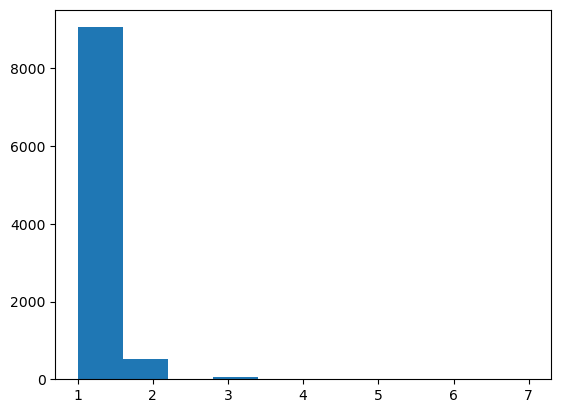

In [16]:
# first check consistency of NT within each type
cb["top_nt"] = cb["top_nt"].fillna("unknown")
nt_count_per_type = cb.groupby("combined_type")["top_nt"].nunique()
plt.hist(nt_count_per_type)

In [17]:
# For those with different NT for each neuron, get the majority NT for each type
nt_conflict_types = nt_count_per_type[nt_count_per_type > 1].index

# Getting counts of top_nt for each combined_type
nt_conflict_type_counts = (
    cb[cb.combined_type.isin(nt_conflict_types)]
    .groupby(["combined_type", "top_nt"])
    .size()
)

# Convert the series to a DataFrame and reset index
nt_conflict_type_counts = nt_conflict_type_counts.reset_index(name="counts")

# Sort by combined_type and counts in descending order
nt_conflict_type_counts.sort_values(
    by=["combined_type", "counts"], ascending=[True, False], inplace=True
)

# Initialize dictionary with existing type-nt matching
type_nt = dict(zip(cb.combined_type, cb.top_nt))
# Initialize a list to keep track of types with equal top_nt counts
types_with_equal_top_nt_counts = []


# Custom function to handle ties, random selection, and record keeping
def select_random_nt_and_record_ties(df):
    max_count = df["counts"].max()
    top_nts = df[df["counts"] == max_count]
    if len(top_nts) > 1:  # If there are ties
        types_with_equal_top_nt_counts.append(
            df["combined_type"].iloc[0]
        )  # Record the type with ties
        random_nt = np.random.choice(top_nts["top_nt"].values)
        while random_nt == "unknown":
            random_nt = np.random.choice(top_nts["top_nt"].values)
        return random_nt  # Random selection among ties
    else:
        return top_nts["top_nt"].values[0]


# Loop through each type to get the top_nt, handling ties appropriately
for atype in nt_conflict_types:
    type_df = nt_conflict_type_counts[nt_conflict_type_counts["combined_type"] == atype]
    top_nt = select_random_nt_and_record_ties(type_df)
    type_nt[atype] = top_nt

len(types_with_equal_top_nt_counts)

232

In [18]:
# the types without any known nt
[atype for atype, nt in type_nt.items() if nt == "unknown"]

['720575940638707901',
 'DNge061',
 '720575940612376690',
 'ITP',
 '720575940626896145',
 '720575940622611917',
 '720575940624156391',
 '720575940632738259',
 '720575940621636988',
 '720575940610239608',
 '720575940623382711',
 '720575940612269283',
 'AN_GNG_204',
 'AN_GNG_124',
 '720575940614957115',
 '720575940626216720',
 '720575940621463699',
 '720575940606375772',
 '720575940610183154',
 '720575940617816661',
 '720575940635901274',
 '720575940612137895',
 '720575940621568490',
 '720575940619617919',
 '720575940628335611',
 '720575940633705560',
 '720575940637470627',
 '720575940639152117',
 '720575940638909429',
 '720575940614736699',
 '720575940611937967',
 '720575940613684274',
 '720575940625771780',
 '720575940619904380',
 '720575940630846125',
 '720575940624211202',
 '720575940611477229',
 '720575940628628055',
 '720575940618759078',
 '720575940629273130',
 '720575940618109460',
 '720575940611810001',
 '720575940628268226',
 '720575940620287820',
 '720575940623758669',
 '72057

In [19]:
# update the top_nt column to be consistent within each type
cb.loc[:, ["top_nt"]] = cb.combined_type.map(type_nt)
cb

,supervoxel_id,root_id,pos_x,pos_y,pos_z,soma_x,soma_y,soma_z,nucleus_id,flow,...,top_nt_conf,known_nt,known_nt_source,side,nerve,vfb_id,fbbt_id,status,combined_type,known_nt_simplified
0,78112261444987077,720575940628857210,109306,50491,3960,104904.0,47464.0,5461.0,2453924.0,intrinsic,...,0.917977,NaN,NaN,left,NaN,fw138205,FBbt_20001935,NaN,PS180,NaN
1,82475466912542440,720575940626838909,172029,55635,1592,177472.0,56936.0,1429.0,7393349.0,intrinsic,...,0.645442,NaN,NaN,right,NaN,fw000001,NaN,NaN,CB0924,NaN
2,83038623024880664,720575940626046919,180632,58664,1925,180632.0,58664.0,1925.0,7415038.0,intrinsic,...,0.844781,NaN,NaN,right,NaN,fw000002,FBbt_20000538,NaN,AVLP429,NaN
3,79801523353604463,720575940630311383,133800,56063,1847,180728.0,61008.0,1630.0,7415013.0,intrinsic,...,0.760387,NaN,NaN,right,NaN,fw000003,FBbt_20000260,NaN,AVLP151,NaN
4,83038554439606237,720575940633370649,180496,57448,2989,180496.0,57448.0,2989.0,7415848.0,intrinsic,...,0.895458,NaN,NaN,right,NaN,fw000004,FBbt_00051248,NaN,LC27,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123502,79587599823629322,720575940618417409,130350,14001,3229,NaN,NaN,NaN,NaN,afferent,...,NaN,NaN,NaN,left,OCN,fw123599,FBbt_00004242,NaN,ocellar retinula cell,NaN
123503,79587599823608864,720575940628941553,130046,14747,3205,NaN,NaN,NaN,NaN,afferent,...,0.734219,NaN,NaN,left,OCN,fw123600,FBbt_00004242,NaN,ocellar retinula cell,NaN
123504,79728680842360672,720575940612567258,132026,19096,3069,NaN,NaN,NaN,NaN,afferent,...,0.729409,NaN,NaN,center,OCN,fw123601,FBbt_00004242,NaN,ocellar retinula cell,NaN
123505,79798912214529467,720575940630757750,133378,17839,3166,NaN,NaN,NaN,NaN,afferent,...,0.544816,NaN,NaN,center,OCN,fw123602,FBbt_00004242,NaN,ocellar retinula cell,NaN


In [20]:
# for now regarding everything (ACh, Glu, GABA, Dopamine, Serotonine, ??) except for Glu and GABA to be excitatory
# first make a dictionary
nt_value = {
    "acetylcholine": 1,
    "glutamate": -1,
    "gaba": -1,
    "dopamine": 1,
    "serotonin": 1,
    "octopamine": 1,
    "unknown": 1,
}

# make coo

In [21]:
conn = conn_full[
    (conn_full.pre_pt_root_id.isin(cb.root_id))
    & (conn_full.post_pt_root_id.isin(cb.root_id))
]
# sum synapse numbers across neuropils
conn = conn.groupby(["pre_pt_root_id", "post_pt_root_id"]).syn_count.sum().reset_index()
conn

,pre_pt_root_id,post_pt_root_id,syn_count
0,720575940600433181,720575940605214636,13
1,720575940600433181,720575940605353649,7
2,720575940600433181,720575940606938313,2
3,720575940600433181,720575940607923721,1
4,720575940600433181,720575940609527069,1
...,...,...,...
9311059,720575940661338497,720575940646930996,3
9311060,720575940661338497,720575940647030580,3
9311061,720575940661338497,720575940647036980,3
9311062,720575940661338497,720575940655015329,1


In [22]:
# instead of making a dense matrix based on the edgelist above, let's make a sparse one from the edgelist directly
# first make a coo matrix
nodes = set(cb.root_id)
sorted_nodes = sorted(nodes)  # Convert the set to a sorted list
nodes_to_idx = {node: num for num, node in enumerate(sorted_nodes)}

# type to type connectivity
conn["pre_idx"] = conn.pre_pt_root_id.map(nodes_to_idx)
conn["post_idx"] = conn.post_pt_root_id.map(nodes_to_idx)

# Create COO matrix
row = conn["pre_idx"].values
col = conn["post_idx"].values
data = conn["syn_count"].values
matrix_size = len(nodes)
coo = coo_matrix((data, (row, col)), shape=(matrix_size, matrix_size))

# then turn it into csc matrix
csc = coo.tocsc()

# calculate the size
csc_size = csc.data.nbytes  # Size of the data array
csc_size += csc.indices.nbytes  # Size of the indices array
csc_size += csc.indptr.nbytes  # Size of the index pointer array
# number of MB
csc_size / 1e6

111.935176

In [23]:
csc.shape

(50601, 50601)

In [24]:
csc

<50601x50601 sparse matrix of type '<class 'numpy.int64'>'
	with 9311064 stored elements in Compressed Sparse Column format>

In [25]:
csc = csc.astype(np.int32)
sp.sparse.save_npz("../data/adult_cb_neuron/adult_cb_syncount.npz", csc)

In [26]:
# calculate the total post-synapses for each neuron
total_post = (
    conn_full[conn_full.post_pt_root_id.isin(nodes)]
    .groupby("post_pt_root_id")
    .syn_count.sum()
)

# some neurons have no postsynapses (receptors). Let's add those to total_post with value of 0
no_post = nodes - set(total_post.index)
no_post_dict = dict(zip(no_post, np.zeros(len(no_post), dtype=int)))
total_post = pd.concat([total_post, pd.Series(no_post_dict)])
total_post

720575940600433181     123
720575940600646173     100
720575940602120928    1330
720575940602132509     161
720575940602309600      32
                      ... 
720575940614890642       0
720575940631769845       0
720575940640372277       0
720575940635609975       0
720575940625912250       0
Length: 50601, dtype: int64

In [27]:
# re-order so that it matches order of nodes
total_post = total_post.loc[sorted_nodes]
total_post

720575940600433181     123
720575940600646173     100
720575940602120928    1330
720575940602132509     161
720575940602309600      32
                      ... 
720575940661329281    1271
720575940661333889     280
720575940661335681    1549
720575940661337217     417
720575940661338497    3377
Length: 50601, dtype: int64

In [28]:
# Handling division by zero in case some columns have a sum of zero
# that is, where a neuron doesn't have incoming synapses
col_sums_with_inversion = np.reciprocal(
    total_post.to_numpy().astype(float), where=total_post.to_numpy() != 0
)
# Multiply each column by the inverse of its sum
inprop = csc.multiply(col_sums_with_inversion)
# and then reduce the precision to float32 to save memory
inprop = inprop.astype(np.float32)

In [29]:
sp.sparse.save_npz("../data/adult_cb_neuron/adult_inprop_cb_neuron.npz", inprop)

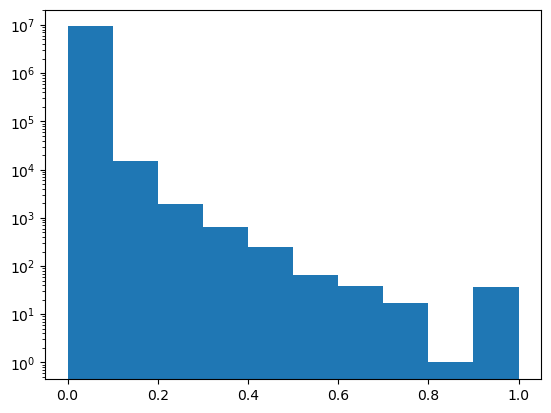

In [30]:
# histogram of connection strengths
plt.hist(inprop.data)
plt.yscale("log")
plt.show()

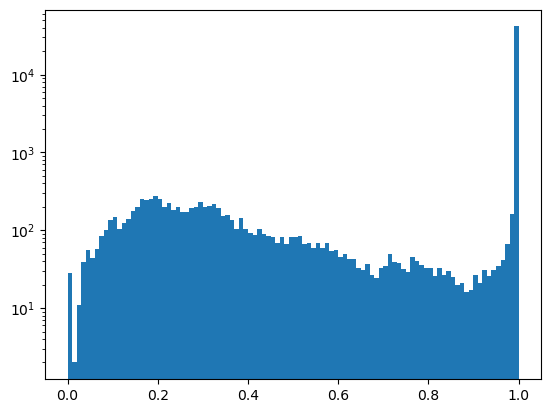

In [31]:
# histogram of column sums
colsums = inprop.sum(axis=0)
plt.hist(colsums.A1, bins=100)
plt.yscale("log")
plt.show()

In [32]:
# save to csv, one row is one neuron
meta = cb[
    [
        "root_id",
        "combined_type",
        "side",
        "top_nt",
        "super_class",
        "cell_class",
        "cell_sub_class",
        "ito_lee_hemilineage",
        "hartenstein_hemilineage",
    ]
]
meta.loc[:, ["idx"]] = meta.root_id.map(nodes_to_idx)
meta.loc[:, ["sign"]] = meta.top_nt.map(nt_value)
meta.rename(columns={"combined_type": "cell_type"}, inplace=True)

# adult, right hemisphere, neuron level, meta information
meta.to_csv("../data/adult_cb_neuron/adult_cb_neuron_meta.csv")

C:\Users\44745\AppData\Local\Temp\ipykernel_65524\1790267967.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta.rename(columns={"combined_type": "cell_type"}, inplace=True)


In [33]:
meta

,root_id,cell_type,side,top_nt,super_class,cell_class,cell_sub_class,ito_lee_hemilineage,hartenstein_hemilineage,idx,sign
0,720575940628857210,PS180,left,acetylcholine,central,NaN,NaN,SMPpv2_ventral,CP1_ventral,33601,1
1,720575940626838909,CB0924,right,acetylcholine,central,NaN,NaN,VLPl2_medial,BLAv2_medial,29427,1
2,720575940626046919,AVLP429,right,acetylcholine,central,NaN,NaN,NaN,NaN,27805,1
3,720575940630311383,AVLP151,right,acetylcholine,central,NaN,NaN,putative_primary,putative_primary,36434,1
4,720575940633370649,LC27,right,acetylcholine,visual_projection,NaN,NaN,NaN,NaN,41325,1
...,...,...,...,...,...,...,...,...,...,...,...
123502,720575940618417409,ocellar retinula cell,left,serotonin,sensory,visual,ocellar,NaN,NaN,13370,1
123503,720575940628941553,ocellar retinula cell,left,serotonin,sensory,visual,ocellar,NaN,NaN,33792,1
123504,720575940612567258,ocellar retinula cell,center,serotonin,sensory,visual,ocellar,NaN,NaN,5939,1
123505,720575940630757750,ocellar retinula cell,center,serotonin,sensory,visual,ocellar,NaN,NaN,37288,1


## ad coo

In [34]:
# calculate the total post-synapses for each neuron
total_post = (
    adconn[adconn.post_root_id.isin(nodes)]
    .groupby("post_root_id")
    .syn_count.sum()
)

# some neurons have no postsynapses (receptors). Let's add those to total_post with value of 0
no_post = nodes - set(total_post.index)
no_post_dict = dict(zip(no_post, np.zeros(len(no_post), dtype=int)))
total_post = pd.concat([total_post, pd.Series(no_post_dict)])
total_post

720575940602120928     856
720575940602313952     160
720575940602380768    1201
720575940602415584     166
720575940602483424    1426
                      ... 
720575940610719730       0
720575940622024692       0
720575940633165816       0
720575940630052857       0
720575940621008895       0
Length: 50601, dtype: int64

In [35]:
# calculate the total pre-synapses for each neuron
total_pre = (
    adconn[adconn.pre_root_id.isin(nodes)].groupby("pre_root_id").syn_count.sum()
)

# some neurons have no presynapses (receptors). Let's add those to total_pre with value of 0
no_pre = nodes - set(total_pre.index)
no_pre_dict = dict(zip(no_pre, np.zeros(len(no_pre), dtype=int)))
total_pre = pd.concat([total_pre, pd.Series(no_pre_dict)])

In [36]:
# coo matrix for axo-dendritic connections 
adconn["pre_idx"] = adconn.pre_root_id.map(nodes_to_idx)
adconn["post_idx"] = adconn.post_root_id.map(nodes_to_idx)

adconn = adconn[adconn.pre_idx.notna() & adconn.post_idx.notna()]

row = adconn['pre_idx'].values
col = adconn['post_idx'].values
data = adconn['syn_count'].values
matrix_size = len(nodes)
ad_coo = coo_matrix((data, (row, col)), shape=(matrix_size, matrix_size))

ad_csc = ad_coo.tocsc()

C:\Users\44745\AppData\Local\Temp\ipykernel_65524\1761448951.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adconn["pre_idx"] = adconn.pre_root_id.map(nodes_to_idx)
C:\Users\44745\AppData\Local\Temp\ipykernel_65524\1761448951.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  adconn["post_idx"] = adconn.post_root_id.map(nodes_to_idx)


In [37]:
# re-order so that it matches order of nodes
total_post = total_post.loc[sorted_nodes]
total_post

720575940600433181       0
720575940600646173       0
720575940602120928     856
720575940602132509       0
720575940602309600       0
                      ... 
720575940661329281     560
720575940661333889     197
720575940661335681    1458
720575940661337217      66
720575940661338497    2768
Length: 50601, dtype: int64

In [38]:
# Handling division by zero in case some columns have a sum of zero
# that is, where a neuron doesn't have incoming synapses
col_sums_with_inversion = np.reciprocal(
    total_post.to_numpy().astype(float), where=total_post.to_numpy() != 0
)
# Multiply each column by the inverse of its sum
inprop = ad_csc.multiply(col_sums_with_inversion)
# and then reduce the precision to float32 to save memory
inprop = inprop.astype(np.float32)

In [39]:
# re-order so that it matches order of nodes
total_pre = total_pre.loc[sorted_nodes]

# Handling division by zero in case some rows have a sum of zero
# that is, where a neuron doesn't have incoming synapses
row_sums_with_inversion = np.reciprocal(
    total_pre.to_numpy().astype(float), where=total_pre.to_numpy() != 0
)
# Multiply each row by the inverse of its sum
outprop = ad_csc.multiply(row_sums_with_inversion[:, None])
# and then reduce the precision to float32 to save memory
outprop = outprop.astype(np.float32)

In [40]:
sp.sparse.save_npz(
    "../data/adult_cb_neuron/fafb_ad_syncount_cb_neuron.npz",
    ad_csc,
)
sp.sparse.save_npz(
    "../data/adult_cb_neuron/fafb_ad_inprop_cb_neuron.npz",
    inprop,
)
sp.sparse.save_npz(
    "../data/adult_cb_neuron/fafb_ad_outprop_cb_neuron.npz",
    outprop,
)